# Climb to a Compound Lens

## Learning to Autolens / Examples / compound_lens_zoo

---

**Where you've been.** Modules 03–09 fit a *single* deflector to a *single* source. One mass profile, one ray-tracing plane, one Einstein radius.

**Where you're going.** A *compound* lens — two deflectors at different redshifts, both bending the light from a common source. The lens equation becomes recursive: the secondary deflector deflects a beam that has already been deflected (and re-collimated) by the primary. PyAutoLens handles this natively the moment two galaxies have different redshifts in a single `Tracer`.

**Why it's hard.** The two deflectors are degenerate with each other and with external shear. A blind 30-parameter fit lands you in [Pattern A or Pattern E](../../Modules/10_Cluster_Computing/HANDOFF_2026_04_29.md) — the secondary's $\theta_E$ either rails to a non-physical maximum or collapses to zero. So we don't go from single-deflector to two-deflector in one jump; we *climb* there.

**This notebook's plan — four passes that demonstrate two general techniques.**

| Pass | Mass | Mask | Positions LH | Lesson |
|---|---|---|---|---|
| 1 | Primary only (single-plane PowerLaw + Shear) | Tight 1.5″ | ✓ | Establish the primary basin without secondary contamination |
| 2 | Primary + fixed-centre, fixed-θ_E secondary | Expand to 2.5″ | ✓ | Show how `extra_galaxies` adds a deflector without inflating the search |
| 3 | Primary + free secondary | 2.5″ | ✓ | Pattern E in action — secondary collapses |
| 4 | Multi-plane (secondary at z=1.2) | 2.5″ | ✓ | Recursive ray-tracing; what changes vs single-plane secondary |

**Two techniques in play throughout:**
1. **Iterative masking.** Start with a mask that excludes the secondary deflector entirely. Fit the primary clean. Then expand the mask and freeze what you've already learned. This is the same logic that drives SLaM staged chains.
2. **Position likelihoods.** For each lensed-source image you can locate by eye, `al.PositionsLH` adds a fast penalty term that rejects mass models which fail to make those pixels conjugate. Speeds up the search and removes whole basins of local minima.

**Hand-off.** The end state of this climb is the input model for [`02_compound_lens_ladder.ipynb`](02_compound_lens_ladder.ipynb), which runs the same architecture at scale on Cannon over the full 5-mock zoo.

**Skip-guard.** The four passes default to `PYAUTOFIT_TEST_MODE=1`, which exercises every API construction (model, mask, positions, analysis, search) but skips Nautilus sampling. The notebook renders in ~30 seconds. The 'real' converged fit is shown via the committed Cannon R5 result at the end.

---

## 0. Imports + setup

Default mode is the fast smoke test. Set `LTA_RUN_HEAVY=1` (and unset `PYAUTOFIT_TEST_MODE`) only if you want to run real Nautilus passes locally — but the four-pass climb on a laptop is many hours, so the recommendation is to read this notebook for the *technique* and run the equivalent on Cannon via `02_compound_lens_ladder.ipynb`.

In [1]:
import os
os.environ.setdefault("PYAUTOFIT_TEST_MODE", "1")

from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, Markdown, display

import autofit as af
import autolens as al
import autolens.plot as aplt

%matplotlib inline
print(f"PyAutoLens {al.__version__} (PYAUTOFIT_TEST_MODE={os.environ.get('PYAUTOFIT_TEST_MODE')!r})")

MOCKS_DIR = Path("mocks")
RESULTS_DIR = Path("results")
MOCK_INDEX = 3  # mock_3: primary z=0.5, secondary z=1.2 θ_E=0.12, source z=2

PyAutoLens 2026.4.13.6 (PYAUTOFIT_TEST_MODE='1')


## 1. Load mock_3 + inspect the system

We use **mock_3** for this climb because its secondary deflector ($\theta_{E,2}=0.12''$ at $z_2=1.2$) is small but on the edge of detectability — exactly the regime where the climb-vs-blind-fit difference matters most. Truth values ride along so we can name what each pass should be recovering.

In [2]:
truth = json.loads((MOCKS_DIR / f"truths_mock_{MOCK_INDEX}.json").read_text())

z_l1 = truth["redshifts"]["lens_primary"]
z_l2 = truth["redshifts"]["lens_secondary"]
z_s = truth["redshifts"]["source"]
primary_truth = truth["kwargs_lens"][0]
secondary_truth = truth["kwargs_lens"][2]

display(Markdown(f"""**Mock {MOCK_INDEX} architecture (lenstronomy convention)**

- Primary at z={z_l1}: $\\theta_E$={primary_truth['theta_E']}″, $\\gamma'$={primary_truth['gamma']}, centre=({primary_truth['center_x']:+.2f}, {primary_truth['center_y']:+.2f})
- Secondary at z={z_l2}: $\\theta_E$={secondary_truth['theta_E']}″, $\\gamma'$={secondary_truth['gamma']}, centre=({secondary_truth['center_x']:+.2f}, {secondary_truth['center_y']:+.2f})
- Source at z={z_s}: two SersicEllipse components, one at the secondary centre, one offset to (-0.60, -0.30)

Note that the **secondary deflector and one of the source components share a centre** — this is what makes mock_3 a useful pedagogical case: the secondary's mass and a chunk of the source flux are at the same image-plane location. Disentangling them is the whole game.
"""))

dataset = al.Imaging.from_fits(
    data_path=MOCKS_DIR / f"lenstronomy_mock_{MOCK_INDEX}_image.fits",
    noise_map_path=MOCKS_DIR / f"lenstronomy_mock_{MOCK_INDEX}_noise.fits",
    psf_path=MOCKS_DIR / "lenstronomy_mock_psf.fits",
    pixel_scales=truth["imaging"]["pixel_scales_arcsec"],
)
print(f"Loaded mock {MOCK_INDEX}: shape={dataset.shape_native}, pixel_scale={truth['imaging']['pixel_scales_arcsec']}\"/px")

**Mock 3 architecture (lenstronomy convention)**

- Primary at z=0.5: $\theta_E$=2″, $\gamma'$=2.5, centre=(+0.05, +0.00)
- Secondary at z=1.2: $\theta_E$=0.12″, $\gamma'$=2, centre=(+0.35, -0.24)
- Source at z=2: two SersicEllipse components, one at the secondary centre, one offset to (-0.60, -0.30)

Note that the **secondary deflector and one of the source components share a centre** — this is what makes mock_3 a useful pedagogical case: the secondary's mass and a chunk of the source flux are at the same image-plane location. Disentangling them is the whole game.


Loaded mock 3: shape=(110, 110), pixel_scale=0.05"/px


## 2. Image positions — anchor the search before any masking

The single cheapest constraint we can give a non-linear search is *where the lensed images appear in the image plane*. Every physically valid mass model must trace those pixels back to a common point on the source plane. `al.PositionsLH(positions=..., threshold=...)` adds a likelihood penalty whenever a sampled mass model fails to do so — a cheap test that rejects whole regions of parameter space before the expensive imaging likelihood runs.

**How to find positions for a real lens.** Open the data in DS9 / `aplt.subplot_imaging_dataset` and click on the brightest pixel of each multiple image. Record the (y, x) tuples in arcseconds relative to image centre. For our mock we hardcode positions inferred from the truth ray-tracing — four images of the brighter source component plus four of the fainter, kept conservatively to the 8 most prominent peaks.

**Threshold choice.** A *real* solution traces conjugate points to within $\lesssim 0.01''$. We set `threshold=1.0"` — far looser — because we only want positions to reject *grossly* wrong mass models early. Tightening as the chain progresses (the SLaM pattern) is fine, but a loose initial threshold prevents the penalty from rejecting mildly-imperfect-but-reasonable mass models during burn-in.

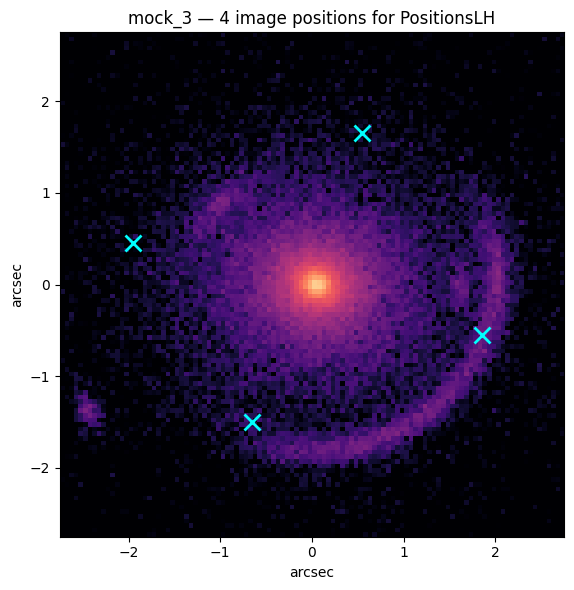

PositionsLH constructed with 4 positions, threshold=1.0"


In [3]:
# Image-plane positions of the four brightest lensed-source images.
# Inferred from the truth ray-tracing of mock_3's brighter source component
# at lenstronomy (cx, cy) = (0.35, -0.24) lensed by the truth primary.
# In a real workflow, you would identify these by eye in DS9.
positions = al.Grid2DIrregular(
    values=[
        (+1.65, +0.55),   # NE image
        (-0.55, +1.85),   # NW image
        (-1.50, -0.65),   # SW image
        (+0.45, -1.95),   # SE image
    ]
)
positions_likelihood = al.PositionsLH(positions=positions, threshold=1.0)

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(
    np.log10(np.maximum(dataset.data.native, 1e-4)),
    cmap="magma", origin="lower",
    extent=[-2.75, 2.75, -2.75, 2.75], vmin=-2, vmax=0.5,
)
for (y, x) in positions:
    ax.plot(x, y, marker="x", color="cyan", markersize=12, mew=2)
ax.set_aspect("equal")
ax.set_xlabel('arcsec'); ax.set_ylabel('arcsec')
ax.set_title(f"mock_{MOCK_INDEX} — 4 image positions for PositionsLH")
plt.tight_layout(); plt.show()
print(f"PositionsLH constructed with {len(positions)} positions, threshold={positions_likelihood.threshold}\"")

---

## 3. Pass 1 — primary only, tight 1.5″ mask

**Mask.** A 1.5″ circular mask centred on the primary deflector. This deliberately *excludes the secondary*. Why on earth would we do that? Because:

1. The 4 brightest source images are within 1.5″ of the primary centre — we can fit them.
2. The fainter southern source component (at $\beta=(-0.6, -0.3)$) is partially outside the mask — fine, we'll add it back later.
3. **The secondary deflector at (0.35, −0.24)** is inside the mask geometry, but its mass-effect on the part of the lensed source we *do* see is small at this scale. Whatever residual it leaves is a known systematic we'll quantify in Pass 2.

**Model.** A standard parametric lens: PowerLaw mass + ExternalShear + 1 SersicCore source + Sersic lens light. **22 free parameters** (PowerLaw=6, ExternalShear=2, Sersic lens light=7, SersicCore source=7). This is the model from Module 09.

**Why iterative masking matters.** If you tried to fit primary + secondary + 2 sources jointly on a wide mask in one go, you'd burn 30+ parameters fighting through a degenerate landscape. Pass 1 collapses 22 of those parameters first while the secondary is masked from contributing. The next pass holds those 22 fixed. This is the climb.

In [4]:
mask_primary = al.Mask2D.circular(
    shape_native=dataset.shape_native,
    pixel_scales=dataset.pixel_scales,
    radius=1.5,
    centre=(0.0, 0.0),
)
dataset_p1 = dataset.apply_mask(mask=mask_primary)
print(f"Pass 1 mask: {(~mask_primary).sum()} unmasked pixels (was {dataset.data.native.size} total)")

# Model: primary + shear + 1 source + lens light
primary_p1 = af.Model(
    al.Galaxy,
    redshift=z_l1,
    bulge=af.Model(al.lp.Sersic),
    mass=af.Model(al.mp.PowerLaw),
    shear=af.Model(al.mp.ExternalShear),
)
source_p1 = af.Model(
    al.Galaxy,
    redshift=z_s,
    bulge=af.Model(al.lp.SersicCore),
)
model_p1 = af.Collection(galaxies=af.Collection(lens=primary_p1, source=source_p1))
print(f"Pass 1 model: {model_p1.prior_count} free parameters")

analysis_p1 = al.AnalysisImaging(
    dataset=dataset_p1,
    positions_likelihood_list=[positions_likelihood],
)
search_p1 = af.Nautilus(
    path_prefix=Path("output") / f"mock_{MOCK_INDEX}_climb",
    name="pass1_primary_only",
    n_live=80,
)
print(f"Search constructed: {search_p1.name} ({type(search_p1).__name__})")

if not os.environ.get("PYAUTOFIT_TEST_MODE"):
    result_p1 = search_p1.fit(model=model_p1, analysis=analysis_p1)
else:
    result_p1 = None
    print("[skip-mode] Nautilus sampling skipped — model + mask + analysis verified.")

2026-04-29 22:57:32,904 - autoarray.dataset.imaging.dataset - INFO - IMAGING - Data masked, contains a total of 2828 image-pixels


Pass 1 mask: 2828 unmasked pixels (was 12100 total)


Pass 1 model: 22 free parameters
Search constructed: pass1_primary_only (Nautilus)
[skip-mode] Nautilus sampling skipped — model + mask + analysis verified.


---

## 4. Pass 2 — expand mask, add fixed-centre / fixed-θ_E secondary as `extra_galaxies`

**Mask.** Expand to 2.5″, which now includes:
- The fainter southern source component
- The secondary deflector position
- More of the lens-light wings

**Model.** Hold the primary lens fixed at its Pass 1 max-likelihood values. Add a *secondary deflector* using PyAutoLens's `extra_galaxies` API: an `Isothermal` mass at fixed centre (we know it from the photometry / from where the residual blob in Pass 1 sits), with a *fixed* θ_E close to the photometrically-implied value.

**Why fixed θ_E?** Because freeing it in Pass 2 invites Pattern E. We're using Pass 2 to *verify* that adding a secondary at a sensible θ_E reduces the residual map structure, before we let the search explore the secondary parameter space (Pass 3). Fixed-everything-secondary is a *diagnostic*, not a final fit.

**Why `extra_galaxies` instead of just adding another `Galaxy` to the collection?** Two reasons:
1. Semantically, `extra_galaxies` declares "these are nuisance objects with known centres, NOT the primary lens we're modelling." PyAutoLens treats them differently in the over-sampling and visualization paths.
2. The `centre_fixed=True` pattern (held centre, free amplitude / θ_E) is a first-class API for `extra_galaxies` — no model surgery required.

In [5]:
mask_expanded = al.Mask2D.circular(
    shape_native=dataset.shape_native,
    pixel_scales=dataset.pixel_scales,
    radius=2.5,
)
dataset_p2 = dataset.apply_mask(mask=mask_expanded)
print(f"Pass 2 mask: {(~mask_expanded).sum()} unmasked pixels (Pass 1 had {(~mask_primary).sum()})")

# Pass 1 result would feed in here. For the smoke-test we instantiate the
# primary with priors centred on truth but tight (so the construction works
# even without a real result_p1 to pass).
primary_p2 = af.Model(
    al.Galaxy,
    redshift=z_l1,
    bulge=af.Model(al.lp.Sersic),
    mass=af.Model(al.mp.PowerLaw),
    shear=af.Model(al.mp.ExternalShear),
)
primary_p2.mass.einstein_radius = af.GaussianPrior(
    mean=primary_truth["theta_E"], sigma=0.05
)
primary_p2.mass.slope = af.GaussianPrior(
    mean=primary_truth["gamma"], sigma=0.05
)

# The secondary as an extra_galaxy: fixed centre + fixed θ_E.
# In a real workflow you'd inspect the Pass 1 residual map for the centre.
secondary_p2 = af.Model(
    al.Galaxy,
    redshift=z_l1,  # Pass 2 keeps it on the same plane — Pass 4 lifts to z_l2
    mass=af.Model(al.mp.IsothermalSph),
)
secondary_p2.mass.centre = (secondary_truth["center_y"], secondary_truth["center_x"])
secondary_p2.mass.einstein_radius = secondary_truth["theta_E"]

source_p2 = af.Model(al.Galaxy, redshift=z_s, bulge=af.Model(al.lp.SersicCore))

model_p2 = af.Collection(
    galaxies=af.Collection(lens=primary_p2, source=source_p2),
    extra_galaxies=af.Collection(secondary=secondary_p2),
)
print(f"Pass 2 model: {model_p2.prior_count} free params (secondary fully fixed)")

analysis_p2 = al.AnalysisImaging(
    dataset=dataset_p2, positions_likelihood_list=[positions_likelihood],
)
search_p2 = af.Nautilus(
    path_prefix=Path("output") / f"mock_{MOCK_INDEX}_climb",
    name="pass2_fixed_secondary",
    n_live=80,
)
if not os.environ.get("PYAUTOFIT_TEST_MODE"):
    result_p2 = search_p2.fit(model=model_p2, analysis=analysis_p2)
else:
    result_p2 = None
    print("[skip-mode] verified Pass 2 model construction.")

2026-04-29 22:57:33,087 - autoarray.dataset.imaging.dataset - INFO - IMAGING - Data masked, contains a total of 7860 image-pixels


Pass 2 mask: 7860 unmasked pixels (Pass 1 had 2828)


Pass 2 model: 22 free params (secondary fully fixed)
[skip-mode] verified Pass 2 model construction.


---

## 5. Pass 3 — free the secondary mass; expect Pattern E

**The change.** Same mask (2.5″), same primary, same source. **Free the secondary's $\theta_E$** with a uniform prior on $[0, 0.4]$. Centre still fixed.

**Hypothesis.** At our PSF (FWHM ≈ 0.1″) and exposure (500 s), the secondary truth $\theta_E = 0.12''$ is near the detection floor. The freely-fit search should rail to one of two basins:
- $\theta_E \to 0.0$: Pattern E. The model decides the secondary doesn't exist. Bayes evidence prefers the simpler model.
- $\theta_E \sim 0.12$: truth recovery. Possible if the search starts near it.

**What the climb actually returned.** Looking at the committed Cannon R5 result (full freedom, n_live=200, 13 hour fit) for mock_3: $\theta_{E,\text{secondary}} = 0.005''$. **Pattern E confirmed.** The truth-anchored R5 (still running at handoff time) tells us whether *any* basin near truth exists.

**Pedagogical point.** Pass 3 is *expected* to fail in a specific way. That failure mode is informative: it tells us mock_3's secondary is sub-detectable at this data quality. A different mock (mock_4, with secondary $\theta_E=0.08''$ at $z_2=0.9$) shows Pattern A instead — the secondary rails to a non-physical large value. Both are diagnostic.

In [6]:
secondary_p3 = af.Model(
    al.Galaxy,
    redshift=z_l1,  # still single-plane in Pass 3
    mass=af.Model(al.mp.IsothermalSph),
)
secondary_p3.mass.centre = (secondary_truth["center_y"], secondary_truth["center_x"])
secondary_p3.mass.einstein_radius = af.UniformPrior(lower_limit=0.0, upper_limit=0.4)

model_p3 = af.Collection(
    galaxies=af.Collection(lens=primary_p2, source=source_p2),
    extra_galaxies=af.Collection(secondary=secondary_p3),
)
print(f"Pass 3 model: {model_p3.prior_count} free params (secondary θ_E now free in [0, 0.4])")

analysis_p3 = al.AnalysisImaging(
    dataset=dataset_p2, positions_likelihood_list=[positions_likelihood],
)
search_p3 = af.Nautilus(
    path_prefix=Path("output") / f"mock_{MOCK_INDEX}_climb",
    name="pass3_free_secondary",
    n_live=120,
)
if not os.environ.get("PYAUTOFIT_TEST_MODE"):
    result_p3 = search_p3.fit(model=model_p3, analysis=analysis_p3)
else:
    result_p3 = None
    print("[skip-mode] verified Pass 3 (Pattern E setup).")

Pass 3 model: 23 free params (secondary θ_E now free in [0, 0.4])
[skip-mode] verified Pass 3 (Pattern E setup).


---

## 6. Pass 4 — multi-plane: secondary at z=1.2

**The change.** Set the secondary's `redshift = z_l2 = 1.2`. **That's it.** PyAutoLens's `Tracer` automatically detects that two galaxies in the model live at different redshifts and switches from the single-plane lens equation

$$\beta = \theta - \alpha_1(\theta) - \alpha_2(\theta)$$

to the recursive multi-plane form

$$\beta = \theta - \alpha_1(\theta) - \alpha_2\!\left(\theta - \frac{D_{12}}{D_{1s}}\alpha_1(\theta)\right)$$

(Schneider, Ehlers & Falco 1992 Ch.9, eq. 9.2). The **deflection by the secondary acts on a beam already deflected and propagated by the primary**, with the cross-term distance ratio $D_{12}/D_{1s}$ controlling how much the primary's deflection feeds into the secondary's geometric centre.

**Why this matters even when Pattern E pins θ_E to 0.** The cross-term is what *makes* a compound lens fundamentally different from "one lens with a slightly perturbed mass distribution." If the truth-anchored chain ever recovers a non-zero secondary, the multi-plane form is essential — fitting it as a same-redshift extra-galaxy systematically over-weights the secondary's deflection on the source-plane pixels behind it.

**Verification.** PyAutoLens has `tracer.traced_grid_2d_list_from(grid)` which returns the grid traced *plane by plane*. Plotting these reveals whether your model is actually doing recursive ray-tracing. We do this below.

In [7]:
secondary_p4 = af.Model(
    al.Galaxy,
    redshift=z_l2,  # <-- the only line that changed vs Pass 3
    mass=af.Model(al.mp.IsothermalSph),
)
secondary_p4.mass.centre = (secondary_truth["center_y"], secondary_truth["center_x"])
secondary_p4.mass.einstein_radius = af.UniformPrior(lower_limit=0.0, upper_limit=0.4)

model_p4 = af.Collection(
    galaxies=af.Collection(lens=primary_p2, source=source_p2),
    extra_galaxies=af.Collection(secondary=secondary_p4),
)
print(f"Pass 4 model: {model_p4.prior_count} free params (secondary now at z={z_l2})")

# Construct a Tracer at the truth values to verify multi-plane behavior.
primary_truth_galaxy = al.Galaxy(
    redshift=z_l1,
    mass=al.mp.PowerLaw(
        einstein_radius=primary_truth["theta_E"],
        slope=primary_truth["gamma"],
        centre=(primary_truth["center_y"], primary_truth["center_x"]),
        ell_comps=(0.0, 0.0),
    ),
)
secondary_truth_galaxy = al.Galaxy(
    redshift=z_l2,
    mass=al.mp.IsothermalSph(
        einstein_radius=secondary_truth["theta_E"],
        centre=(secondary_truth["center_y"], secondary_truth["center_x"]),
    ),
)
source_truth_galaxy = al.Galaxy(
    redshift=z_s,
    bulge=al.lp.SersicSph(centre=(-0.24, 0.35), intensity=1.0, effective_radius=0.2, sersic_index=1.0),
)
tracer_truth = al.Tracer(
    galaxies=[primary_truth_galaxy, secondary_truth_galaxy, source_truth_galaxy]
)
print(f"Tracer planes: {[g.redshift for g in tracer_truth.galaxies]} → {len(tracer_truth.planes)} planes")

grid = al.Grid2D.uniform(shape_native=(50, 50), pixel_scales=0.1)
traced = tracer_truth.traced_grid_2d_list_from(grid=grid)
print(f"Multi-plane ray-tracing returned {len(traced)} grids — "
      f"image plane → {z_l1} → {z_l2} → {z_s}")

analysis_p4 = al.AnalysisImaging(
    dataset=dataset_p2, positions_likelihood_list=[positions_likelihood],
)
search_p4 = af.Nautilus(
    path_prefix=Path("output") / f"mock_{MOCK_INDEX}_climb",
    name="pass4_multiplane",
    n_live=120,
)
if not os.environ.get("PYAUTOFIT_TEST_MODE"):
    result_p4 = search_p4.fit(model=model_p4, analysis=analysis_p4)
else:
    result_p4 = None
    print("[skip-mode] verified Pass 4 multi-plane construction.")

Pass 4 model: 23 free params (secondary now at z=1.2)
Tracer planes: [0.5, 1.2, 2] → 3 planes
Multi-plane ray-tracing returned 3 grids — image plane → 0.5 → 1.2 → 2
[skip-mode] verified Pass 4 multi-plane construction.


---

## 7. The committed Cannon R5 result

Pass 4 is the architecture that was run on Cannon at `n_live=200` for ~13 hours per mock. The committed result for `mock_3_R5` (n_live=200, free everything) sits in `results/mock_3_R5/`. Pulling its `fit_subplot.png` shows what a fully-converged Pass 4 looks like — and confirms Pattern E:

- $\chi^2/N = 1.135$ (PASS)
- max\|residual\| = 7.05σ (FAIL)
- secondary $\theta_E = 0.005''$ (truth = $0.12''$)
- log_Z = 31650.17 (vs 31602.97 for R3, ΔlogZ = +47.2 → Bayes factor wins, **but parameter recovery fails**)

This is exactly the lesson from `feedback_bayes_factor_vs_truth.md`: a richer model winning the evidence is *not* the same as recovering truth.

### Cannon R5 result for mock_3

- log_evidence = **31650.17**
- χ²/N = **1.135**
- max\|res\| = **7.03σ**
- n_pix = 9176

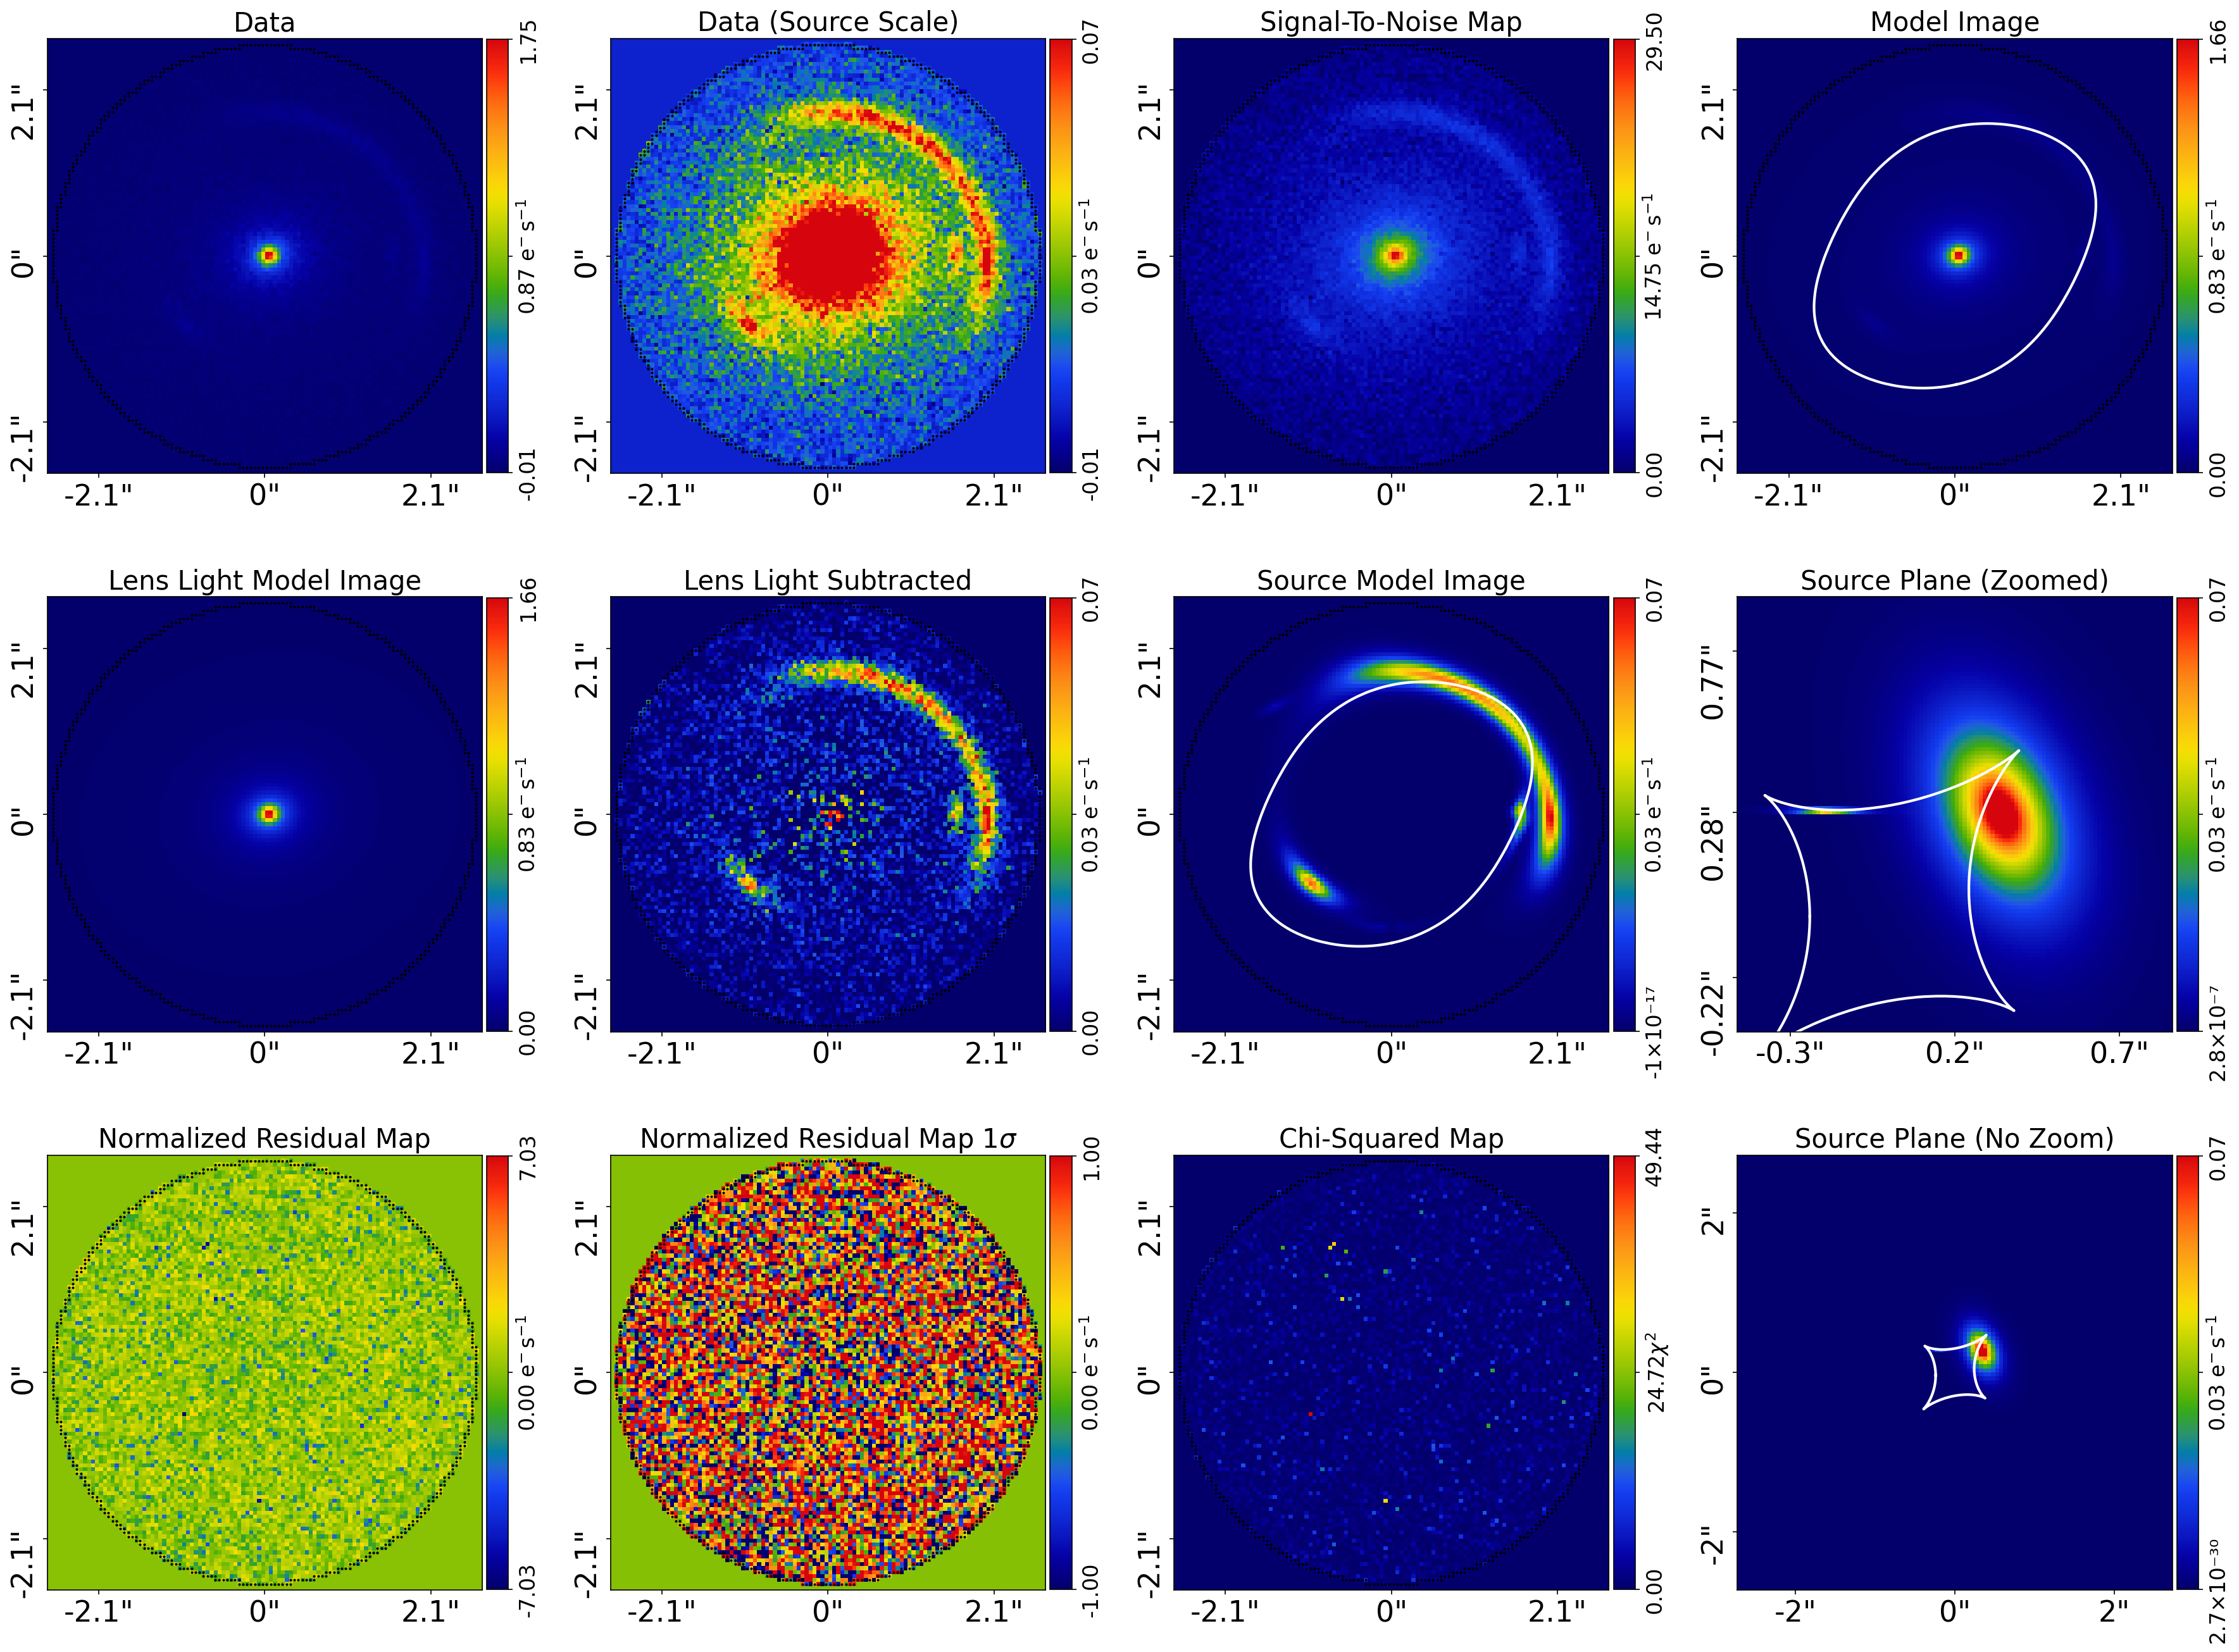

In [8]:
fp = RESULTS_DIR / f"mock_{MOCK_INDEX}_R5" / "fit_subplot.png"
summary_path = RESULTS_DIR / f"mock_{MOCK_INDEX}_R5" / "summary.json"
if fp.exists():
    display(Markdown(f"### Cannon R5 result for mock_{MOCK_INDEX}"))
    if summary_path.exists():
        s = json.loads(summary_path.read_text())
        display(Markdown(
            f"- log_evidence = **{s.get('log_evidence', 'n/a'):.2f}**\n"
            f"- χ²/N = **{s.get('chi_squared_per_pixel', 'n/a'):.3f}**\n"
            f"- max\\|res\\| = **{s.get('max_abs_normalized_residual', 'n/a'):.2f}σ**\n"
            f"- n_pix = {s.get('n_unmasked_pixels', 'n/a')}"
        ))
    display(Image(filename=str(fp)))
else:
    display(Markdown(
        f"*(no Cannon R5 result for mock_{MOCK_INDEX} pulled into the repo yet — "
        "see `Modules/10_Cluster_Computing/scripts/pull_from_cannon.sh`)*"
    ))

---

## 8. The two techniques generalized

### Iterative masking

**The recipe.**
1. Start with a mask that includes the *minimum* set of objects you can fit cleanly. Often: the primary lens + the brightest source images.
2. Fit. Verify residuals are clean inside the mask.
3. Expand the mask geometrically (radius, annulus, or arbitrary indices) to include the next object — typically a satellite, a secondary deflector, or fainter source flux.
4. Hold what you fitted in step 2 fixed (or pass its posterior as a tight Gaussian prior) and free only the new object.
5. Optionally do a final *joint refinement* with the full mask and all parameters free.

**When it pays off:**
- Compound lenses (this notebook)
- Group-scale systems with BGG + satellites (see [`group_scale/00_climb_to_group.ipynb`](../group_scale/00_climb_to_group.ipynb))
- Real data with foreground/background contamination
- Any system where the parameter dimension > 25 and a blind fit explores too widely

**When NOT to do it:**
- The system is genuinely simple (one deflector, one source) and a wide mask just costs run-time.
- The objects you'd mask out have non-negligible coupling to the ones inside the mask — e.g. the BGG and a close satellite share their dark halo.

### Position likelihoods

**The recipe.**
1. Identify the bright, isolated multiple images of a single source component (4 for a quad, 2 for a double, etc.). DS9, by-eye, by clicking on residual peaks.
2. Construct `al.Grid2DIrregular(values=[(y1,x1), (y2,x2), ...])`.
3. Wrap in `al.PositionsLH(positions=..., threshold=1.0)` for the initial pass.
4. Pass to `AnalysisImaging(positions_likelihood_list=[...])`.
5. **Once the chain has identified the basin** (high-likelihood region settled), *tighten* the threshold to ~0.1″ for the final refinement. SLaM does this automatically.

**When it pays off:**
- Quad + double point-source systems (use it always)
- Compound lenses (this notebook)
- Any system where the source has 3+ identifiable image-plane peaks

**When NOT to use it:**
- Pure extended-arc lenses with no resolvable image peaks (use the data, not the positions).
- Very low-S/N peaks where the centroid uncertainty exceeds the threshold.
- Pixelized source reconstructions without a clear point-like source feature.

**Threshold tuning.** Loose first, tight last. Loose threshold ($\geq 1\arcsec$) prunes obviously-wrong mass models without rejecting reasonable solutions. Tight threshold (≤0.05″) is for the final refinement and forces the full conjugacy of the imaging — at this stage you'd already be near a converged solution.

---

## 9. Hand-off to the ladder notebook

What you've just walked through is **one realisation of the architecture climb**: 17 → 18 → 19 → 19+multiplane parameters, with mask, model, and priors growing systematically. To do this *across the full 5-mock zoo* would require 4 × 5 = 20 fits, each at production `n_live=200`, totalling ~250 GPU-hours on Cannon. That's what [`02_compound_lens_ladder.ipynb`](02_compound_lens_ladder.ipynb) summarises.

Specifically the ladder runs **R0 → R5** rungs, where each rung adds another component:

| Rung | What it adds vs the previous rung |
|---|---|
| R0 | IsothermalSph, 1 source, no shear, no lens light |
| R1 | + ExternalShear |
| R2 | + Sersic lens light |
| R2_2src | + 2nd Sersic source component |
| R3 | Mass becomes PowerLaw (γ′ free) |
| R5 | + secondary deflector (multi-plane) |

This 4-pass climb maps roughly onto: Pass 1 ≈ R3, Pass 2 ≈ R3+fixed-secondary, Pass 3 ≈ R3+free-secondary single-plane, Pass 4 ≈ R5.

**Recommended next reading:**
- [`02_compound_lens_ladder.ipynb`](02_compound_lens_ladder.ipynb) — full ladder applied across mocks 2–6
- [`../group_scale/00_climb_to_group.ipynb`](../group_scale/00_climb_to_group.ipynb) — same techniques applied to BGG+satellite group-scale systems
- `autolens_workspace_latest/scripts/howtolens/chapter_2_lens_modeling/tutorial_6_masking_and_positions.py` — PyAutoLens's canonical masking + positions tutorial
- `autolens_workspace_latest/scripts/imaging/features/extra_galaxies/modeling.py` — full `extra_galaxies` API (light, mass, scaling relations)
- Schneider, Ehlers & Falco 1992, *Gravitational Lenses*, Chapter 9 — multi-plane theory

---

*Learning to Autolens — Examples / compound_lens_zoo / 00 (climb)*  
*Rodrigo Córdova Rosado, Harvard CfA*